*@author: petra.boskovic*

# 1. Install and Import Libraries

In [1]:
#!pip install -q kagglehub xgboost

In [2]:
import os
import gc
import glob
import time
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats as sp_stats
from scipy.signal import butter, sosfiltfilt, resample_poly, welch, find_peaks

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV, LeaveOneGroupOut
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
)

from xgboost import XGBClassifier

import kagglehub
warnings.filterwarnings("ignore")

In [3]:
np.random.seed(42)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# 2. Configuration

In [4]:
# 60 s windows are the de-facto standard for WESAD: they are long enough to
# estimate heart-rate variability and respiration rate reliably (a 60 s window
# contains ~60-100 heart beats and ~15 breaths), and short enough that the
# affective state is stationary inside the window.
WINDOW_SEC = 60.0
# 15 s shift => 75 % overlap. This multiplies the number of training samples by
# 4 compared to non-overlapping windows, which matters a lot because the raw
# dataset only holds ~36 minutes of usable labelled signal per subject.
# Overlapping windows are highly correlated, which is exactly why the
# evaluation protocol below is Leave-One-Subject-Out: no subject ever appears
# in both train and test, so the overlap cannot leak.
STEP_SEC = 15.0
# A window is only accepted if at least this fraction of its 700 Hz label
# samples carry one single class. This removes transition windows that straddle
# two conditions.
LABEL_PURITY = 0.98

In [5]:
KEEP_LABELS = {1: "baseline", 2: "stress", 3: "amusement"}
CLASS_ORDER = ["baseline", "stress", "amusement"]

In [6]:
# Chest signals are decimated to the lowest rate that still preserves the
# physiology, which cuts feature-extraction time and memory by ~10x:
#   ECG  700 Hz : kept, R-peak timing accuracy (~1.4 ms) drives all HRV features
#   EMG  700 Hz : kept, muscle activity energy lives at 50-350 Hz
#   Resp  70 Hz : breathing is < 1 Hz, 70 Hz is already 70x oversampled
#   ACC   70 Hz : human motion is < 20 Hz
#   EDA    7 Hz : skin-conductance responses are < 1 Hz (E4 itself samples 4 Hz)
#   Temp   7 Hz : skin temperature drifts over tens of seconds
CHEST_TARGET_FS = {
    "ECG": 700.0,
    "EMG": 700.0,
    "Resp": 70.0,
    "ACC": 70.0,
    "EDA": 7.0,
    "Temp": 7.0,
}

In [7]:
# Wrist signals are already low-rate, so they are used at their native rate.
WRIST_FS = {"ACC": 32.0, "BVP": 64.0, "EDA": 4.0, "TEMP": 4.0}

In [8]:
USE_CHEST = True
USE_WRIST = True

In [9]:
# Hyperparameter search uses grouped K-fold (groups = subjects) on the full
# feature table, the final score comes from Leave-One-Subject-Out.
TUNING_FOLDS = 5
N_JOBS = -1
RANDOM_STATE = 42

In [10]:
RUN_NESTED_CV = False

In [11]:
print(f"Window: {WINDOW_SEC:.0f} s, step: {STEP_SEC:.0f} s, classes: {list(KEEP_LABELS.values())}")

Window: 60 s, step: 15 s, classes: ['baseline', 'stress', 'amusement']


# 3. Download Dataset with kagglehub

In [12]:
DATA_ROOT = kagglehub.dataset_download(
    "orvile/wesad-wearable-stress-affect-detection-dataset"
)
print("Dataset root:", DATA_ROOT)

100%|██████████| 2.43G/2.43G [00:28<00:00, 90.9MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1


In [13]:
PKL_FILES = sorted(
    glob.glob(os.path.join(DATA_ROOT, "**", "S*.pkl"), recursive=True)
)

In [14]:
# Drop any non-subject pickle that may sit in the archive.
PKL_FILES = [p for p in PKL_FILES if os.path.basename(p)[1:-4].isdigit()]

In [15]:
# Sort numerically (S2, S3, ..., S17) instead of lexicographically (S10 < S2).
PKL_FILES.sort(key=lambda p: int(os.path.basename(p)[1:-4]))

In [16]:
print(f"Found {len(PKL_FILES)} subject pickles:")
for p in PKL_FILES:
    print("  ", os.path.basename(p), f"({os.path.getsize(p) / 1e6:.0f} MB)")

Found 15 subject pickles:
   S2.pkl (975 MB)
   S3.pkl (1032 MB)
   S4.pkl (1034 MB)
   S5.pkl (993 MB)
   S6.pkl (1123 MB)
   S7.pkl (829 MB)
   S8.pkl (869 MB)
   S9.pkl (833 MB)
   S10.pkl (867 MB)
   S11.pkl (831 MB)
   S13.pkl (885 MB)
   S14.pkl (881 MB)
   S15.pkl (828 MB)
   S16.pkl (899 MB)
   S17.pkl (947 MB)


# 4. Inspect Raw Dataset Structure

In [17]:
def peek_pickle(pkl_path):
    """Print the structure of a single WESAD subject pickle."""
    with open(pkl_path, "rb") as f:
        # encoding="latin1" is mandatory: the files are Python 2 pickles.
        data = pickle.load(f, encoding="latin1")

    print("Top-level keys:", list(data.keys()))
    print("Subject:", data["subject"])

    label = np.asarray(data["label"]).ravel()
    print(f"Label array: shape={label.shape}, dtype={label.dtype}")
    uniq, cnt = np.unique(label, return_counts=True)
    for u, c in zip(uniq, cnt):
        # Labels are sampled at 700 Hz, so count / 700 = seconds.
        print(f"  label {u}: {c:>9} samples = {c / 700.0 / 60.0:6.2f} min")

    for device in ["chest", "wrist"]:
        print(f"\n[{device}]")
        for name, arr in data["signal"][device].items():
            arr = np.asarray(arr)
            print(f"  {name:<5} shape={str(arr.shape):<14} dtype={arr.dtype}")
    return data

In [18]:
_probe = peek_pickle(PKL_FILES[0])

Top-level keys: ['signal', 'label', 'subject']
Subject: S2
Label array: shape=(4255300,), dtype=int32
  label 0:   2142701 samples =  51.02 min
  label 1:    800800 samples =  19.07 min
  label 2:    430500 samples =  10.25 min
  label 3:    253400 samples =   6.03 min
  label 4:    537599 samples =  12.80 min
  label 6:     45500 samples =   1.08 min
  label 7:     44800 samples =   1.07 min

[chest]
  ACC   shape=(4255300, 3)   dtype=float64
  ECG   shape=(4255300, 1)   dtype=float64
  EMG   shape=(4255300, 1)   dtype=float64
  EDA   shape=(4255300, 1)   dtype=float64
  Temp  shape=(4255300, 1)   dtype=float32
  Resp  shape=(4255300, 1)   dtype=float64

[wrist]
  ACC   shape=(194528, 3)    dtype=float64
  BVP   shape=(389056, 1)    dtype=float64
  EDA   shape=(24316, 1)     dtype=float64
  TEMP  shape=(24316, 1)     dtype=float64


In [19]:
# Free the ~1 GB of raw arrays immediately, Colab RAM is limited.
del _probe
gc.collect()

30

# 5. Signal Loading and Resampling Helpers

In [20]:
def _normalise_keys(d):
    """Decode bytes keys to str. Some Kaggle mirrors are re-pickled and end up
    with bytes keys, this makes the loader work with either variant."""
    out = {}
    for k, v in d.items():
        out[k.decode("utf-8") if isinstance(k, bytes) else k] = v
    return out

In [21]:
def downsample(x, fs_in, fs_out):
    """Anti-aliased decimation by an integer factor.

    resample_poly applies an FIR low-pass before decimating, so it cannot
    alias, unlike plain slicing (x[::q]) which folds high-frequency noise back
    into the band of interest. Works on 1-D and on (N, 3) accelerometer data.
    """
    x = np.asarray(x, dtype=np.float64)
    if fs_out >= fs_in:
        return x.astype(np.float32)
    q = int(round(fs_in / fs_out))
    return resample_poly(x, up=1, down=q, axis=0).astype(np.float32)

In [22]:
def load_subject(pkl_path):
    """Load one subject and return (channels, labels_700hz, subject_id).

    channels maps a channel name -> (array, sampling_rate). Every array starts
    at the same physical t = 0, so a window in seconds can be sliced from each
    channel independently using its own rate.
    """
    with open(pkl_path, "rb") as f:
        data = _normalise_keys(pickle.load(f, encoding="latin1"))

    subject = data.get("subject", os.path.basename(pkl_path).split(".")[0])
    if isinstance(subject, bytes):
        subject = subject.decode("utf-8")

    labels = np.asarray(data["label"]).ravel().astype(np.int8)
    signals = _normalise_keys(data["signal"])
    channels = {}

    if USE_CHEST:
        chest = _normalise_keys(signals["chest"])
        for name, target_fs in CHEST_TARGET_FS.items():
            arr = np.asarray(chest[name], dtype=np.float64)
            arr = downsample(arr, 700.0, target_fs)
            if name == "ACC":
                # Split the 3 axes into separate channels plus the magnitude,
                # which is orientation-invariant and therefore more robust.
                for i, axis in enumerate("xyz"):
                    channels[f"chest_ACC{axis}"] = (arr[:, i], target_fs)
                mag = np.sqrt((arr.astype(np.float64) ** 2).sum(axis=1))
                channels["chest_ACCmag"] = (mag.astype(np.float32), target_fs)
            else:
                channels[f"chest_{name}"] = (arr.ravel(), target_fs)

    if USE_WRIST:
        wrist = _normalise_keys(signals["wrist"])
        for name, fs in WRIST_FS.items():
            arr = np.asarray(wrist[name], dtype=np.float32)
            if name == "ACC":
                arr = arr.reshape(-1, 3)
                for i, axis in enumerate("xyz"):
                    channels[f"wrist_ACC{axis}"] = (arr[:, i], fs)
                mag = np.sqrt((arr.astype(np.float64) ** 2).sum(axis=1))
                channels["wrist_ACCmag"] = (mag.astype(np.float32), fs)
            else:
                channels[f"wrist_{name}"] = (arr.ravel(), fs)

    del data, signals
    gc.collect()
    return channels, labels, subject

In [23]:
def window_label(labels, t0, t1, fs_label=700.0):
    """Return the class name of a window, or None if the window is impure or
    belongs to a class we do not model."""
    seg = labels[int(t0 * fs_label): int(t1 * fs_label)]
    if seg.size == 0:
        return None
    values, counts = np.unique(seg, return_counts=True)
    top = values[np.argmax(counts)]
    if counts.max() / seg.size < LABEL_PURITY:
        return None                      # transition window, discard
    return KEEP_LABELS.get(int(top))     # None if class is not in KEEP_LABELS

# 6. Data Exploration: Labels, Signal Lengths, Sample Plots

## 6a. Per-subject duration of every protocol condition. This is a sanity check.

In [24]:
LABEL_NAMES_ALL = {
    0: "transient", 1: "baseline", 2: "stress", 3: "amusement",
    4: "meditation", 5: "ignore_5", 6: "ignore_6", 7: "ignore_7",
}

In [25]:
rows = []
for pkl in PKL_FILES:
    with open(pkl, "rb") as f:
        d = _normalise_keys(pickle.load(f, encoding="latin1"))
    lab = np.asarray(d["label"]).ravel()
    subj = d.get("subject", os.path.basename(pkl).split(".")[0])
    row = {"subject": subj, "total_min": len(lab) / 700.0 / 60.0}
    for code, name in LABEL_NAMES_ALL.items():
        row[name] = float((lab == code).sum()) / 700.0 / 60.0  # minutes
    rows.append(row)
    del d, lab
    gc.collect()

In [26]:
label_df = pd.DataFrame(rows).set_index("subject").round(2)
print("Condition duration per subject (minutes):")
print(label_df)
print("\nTotals across all subjects (minutes):")
print(label_df.sum().round(1))

Condition duration per subject (minutes):
         total_min  transient  baseline  stress  amusement  meditation  ignore_5  ignore_6  ignore_7
subject                                                                                             
S2          101.32      51.02     19.07   10.25       6.03       12.80      0.00      1.08      1.07
S3          108.22      55.85     19.00   10.67       6.25       13.00      1.22      1.12      1.12
S4          107.05      55.10     19.30   10.58       6.20       13.42      0.85      0.73      0.87
S5          104.30      51.02     19.97   10.75       6.23       13.23      1.20      0.73      1.17
S6          117.85      65.08     19.67   10.83       6.20       13.12      0.97      0.83      1.15
S7           87.30      35.05     19.77   10.67       6.20       13.17      0.83      0.73      0.88
S8           91.10      38.48     19.48   11.17       6.17       13.27      0.82      0.85      0.87
S9           87.05      34.18     19.67   10.75  

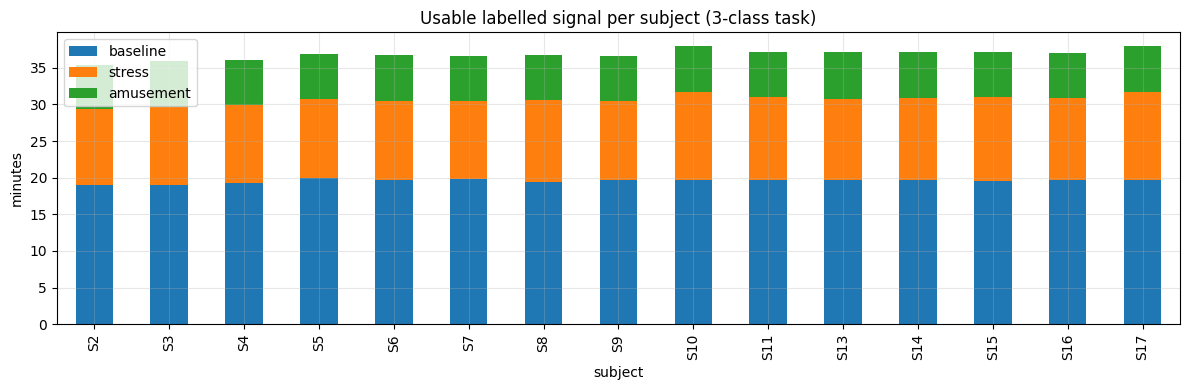

In [27]:
ax = label_df[["baseline", "stress", "amusement"]].plot(
    kind="bar", stacked=True, figsize=(12, 4)
)
ax.set_ylabel("minutes")
ax.set_title("Usable labelled signal per subject (3-class task)")
plt.tight_layout()
plt.show()

## 6b. Raw signal inspection for one subject, with the protocol shaded in

In [28]:
demo_channels, demo_labels, demo_subject = load_subject(PKL_FILES[0])

In [29]:
print(f"\nChannels for {demo_subject}:")
for name, (arr, fs) in demo_channels.items():
    print(f"  {name:<14} n={arr.size:>9}  fs={fs:>6.1f} Hz  "
          f"duration={arr.size / fs / 60:6.2f} min  "
          f"NaNs={int(np.isnan(arr).sum())}")


Channels for S2:
  chest_ECG      n=  4255300  fs= 700.0 Hz  duration=101.32 min  NaNs=0
  chest_EMG      n=  4255300  fs= 700.0 Hz  duration=101.32 min  NaNs=0
  chest_Resp     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCx     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCy     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCz     n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_ACCmag   n=   425530  fs=  70.0 Hz  duration=101.32 min  NaNs=0
  chest_EDA      n=    42553  fs=   7.0 Hz  duration=101.32 min  NaNs=0
  chest_Temp     n=    42553  fs=   7.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCx     n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCy     n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCz     n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_ACCmag   n=   194528  fs=  32.0 Hz  duration=101.32 min  NaNs=0
  wrist_BVP      n=   389056  fs=  64.0 Hz  du

In [30]:
# Sanity check: every channel must cover roughly the same wall-clock duration.
durations = {n: a.size / fs for n, (a, fs) in demo_channels.items()}
print(f"\nDuration spread across channels: "
      f"min={min(durations.values()):.1f}s, max={max(durations.values()):.1f}s")


Duration spread across channels: min=6079.0s, max=6079.0s


In [31]:
# Shade the label track behind the signals so the protocol is visible.
LABEL_COLORS = {1: "tab:green", 2: "tab:red", 3: "tab:orange", 4: "tab:blue"}

In [32]:
def shade_conditions(ax, labels, fs_label=700.0):
    """Shade contiguous blocks of labels 1-4 on a time axis in seconds."""
    changes = np.flatnonzero(np.diff(labels)) + 1
    bounds = np.concatenate(([0], changes, [labels.size]))
    for s, e in zip(bounds[:-1], bounds[1:]):
        code = int(labels[s])
        if code in LABEL_COLORS:
            ax.axvspan(s / fs_label, e / fs_label,
                       color=LABEL_COLORS[code], alpha=0.15, lw=0)

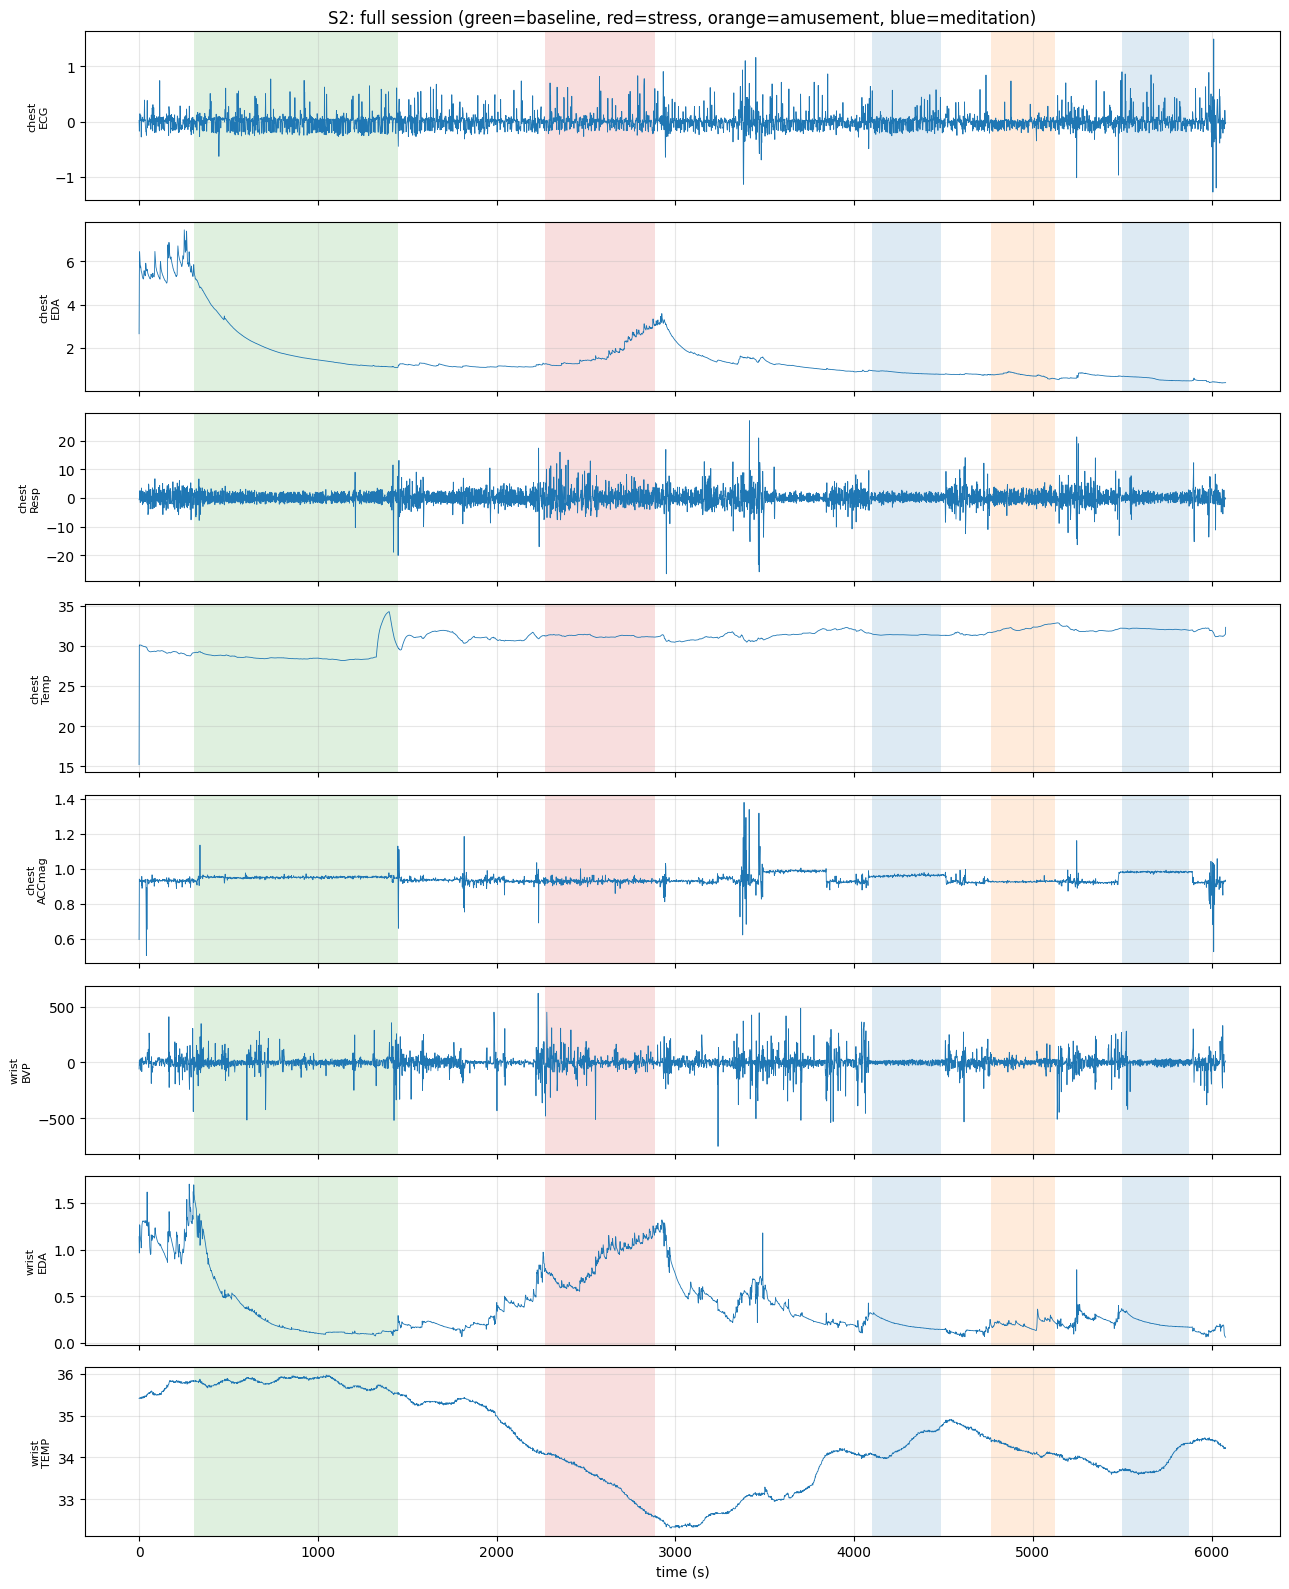

In [33]:
plot_channels = ["chest_ECG", "chest_EDA", "chest_Resp", "chest_Temp",
                 "chest_ACCmag", "wrist_BVP", "wrist_EDA", "wrist_TEMP"]
plot_channels = [c for c in plot_channels if c in demo_channels]

fig, axes = plt.subplots(len(plot_channels), 1, figsize=(13, 2.0 * len(plot_channels)),
                         sharex=True)
for ax, name in zip(np.atleast_1d(axes), plot_channels):
    arr, fs = demo_channels[name]
    # Plot at most ~4000 points per channel, otherwise the figure is unreadable
    # and slow. This is display-only decimation, the features use full rate.
    step = max(1, arr.size // 4000)
    t = np.arange(0, arr.size, step) / fs
    ax.plot(t, arr[::step], lw=0.6)
    ax.set_ylabel(name.replace("_", "\n"), fontsize=8)
    shade_conditions(ax, demo_labels)
np.atleast_1d(axes)[-1].set_xlabel("time (s)")
np.atleast_1d(axes)[0].set_title(
    f"{demo_subject}: full session (green=baseline, red=stress, "
    f"orange=amusement, blue=meditation)"
)
plt.tight_layout()
plt.show()

## 6c. Zoom on 20 s of ECG per condition. Visual confirmation that the ECG is clean enough for R-peak detection and that heart rate visibly rises in the stress condition.

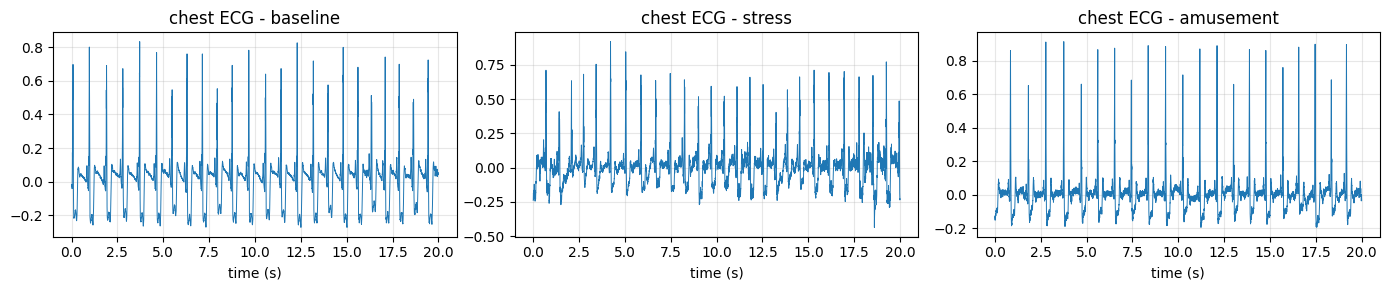

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, (code, name) in zip(axes, [(1, "baseline"), (2, "stress"), (3, "amusement")]):
    idx = np.flatnonzero(demo_labels == code)
    ecg, fs = demo_channels["chest_ECG"]
    # Start 60 s into the block to skip the onset transient.
    start = int(idx[0] / 700.0 * fs) + int(60 * fs)
    seg = ecg[start:start + int(20 * fs)]
    ax.plot(np.arange(seg.size) / fs, seg, lw=0.7)
    ax.set_title(f"chest ECG - {name}")
    ax.set_xlabel("time (s)")
plt.tight_layout()
plt.show()

In [35]:
del demo_channels, demo_labels
gc.collect()

31346

# 7. Windowing and Feature Extraction Functions

**Strategy**: hand-crafted physiological features on 60 s windows. This is the approach that works best on WESAD because the dataset is tiny in ML terms (15 subjects), so a deep model on raw signals would mostly memorise subjects. Every feature below is a scalar summarising one channel of one window.

In [36]:
EPS = 1e-12

In [37]:
def _clean(x):
    """Replace NaN/Inf by finite values. WESAD is largely gap-free, but the E4
    can drop samples, and derived quantities (slopes, ratios) can still produce
    non-finite values on flat segments. Imputation happens once, here, so the
    feature table is guaranteed numeric."""
    x = np.asarray(x, dtype=np.float64).ravel()
    if not np.all(np.isfinite(x)):
        finite = x[np.isfinite(x)]
        fill = float(np.median(finite)) if finite.size else 0.0
        x = np.where(np.isfinite(x), x, fill)
    return x

In [38]:
def stat_features(x, prefix, extended=True):
    """Time-domain statistics.

    mean/std/min/max capture the level and the spread (e.g. tonic skin
    conductance level rises under stress). slope captures the trend inside the
    window (skin temperature falls under stress through vasoconstriction).
    mean_abs_diff and RMS of the first difference capture signal roughness
    (muscle tension, motion). skew/kurtosis capture asymmetry and burstiness.
    """
    x = _clean(x)
    n = x.size
    if n < 3:
        keys = ["mean", "std", "min", "max", "range", "median", "iqr", "rms",
                "mad", "slope", "mean_abs_diff", "rms_diff", "skew", "kurtosis",
                "zcr"]
        return {f"{prefix}_{k}": 0.0 for k in keys}

    d = np.diff(x)
    q25, q75 = np.percentile(x, [25, 75])
    # Least-squares slope in units per second is fs-dependent, so we normalise
    # the time axis to [0, 1]: the slope is then "change across the window".
    t = np.linspace(0.0, 1.0, n)
    slope = float(np.polyfit(t, x, 1)[0]) if np.std(x) > EPS else 0.0

    out = {
        f"{prefix}_mean": float(np.mean(x)),
        f"{prefix}_std": float(np.std(x)),
        f"{prefix}_min": float(np.min(x)),
        f"{prefix}_max": float(np.max(x)),
        f"{prefix}_range": float(np.max(x) - np.min(x)),
        f"{prefix}_slope": slope,
        f"{prefix}_mean_abs_diff": float(np.mean(np.abs(d))),
    }
    if extended:
        out.update({
            f"{prefix}_median": float(np.median(x)),
            f"{prefix}_iqr": float(q75 - q25),
            f"{prefix}_rms": float(np.sqrt(np.mean(x ** 2))),
            f"{prefix}_mad": float(np.mean(np.abs(x - np.mean(x)))),
            f"{prefix}_rms_diff": float(np.sqrt(np.mean(d ** 2))),
            f"{prefix}_skew": float(sp_stats.skew(x)) if np.std(x) > EPS else 0.0,
            f"{prefix}_kurtosis": float(sp_stats.kurtosis(x)) if np.std(x) > EPS else 0.0,
            # Zero crossings of the mean-removed signal: a cheap proxy for the
            # dominant frequency that is robust to amplitude scaling.
            f"{prefix}_zcr": float(np.mean(np.abs(np.diff(np.signbit(x - np.mean(x)))))),
        })
    return out

In [39]:
def psd(x, fs):
    """Welch power spectral density. Welch averages periodograms over
    overlapping sub-segments, which trades frequency resolution for a much
    lower-variance estimate: the right trade-off for feature extraction."""
    x = _clean(x)
    if x.size < 8:
        return np.zeros(1), np.zeros(1)
    nperseg = int(min(x.size, max(8, 8 * fs)))  # 8 s sub-windows -> 0.125 Hz bins
    f, p = welch(x, fs=fs, nperseg=nperseg, detrend="constant")
    return f, p

In [40]:
def freq_features(x, fs, prefix, bands):
    """Frequency-domain features: relative band powers plus spectral shape.

    Relative (not absolute) band powers are used so the features are invariant
    to sensor gain and to subject-specific signal amplitude, which improves
    generalisation to unseen subjects.
    """
    f, p = psd(x, fs)
    total = float(p.sum()) + EPS
    out = {}
    for lo, hi, name in bands:
        mask = (f >= lo) & (f < hi)
        out[f"{prefix}_bp_{name}"] = float(p[mask].sum()) / total
    if p.size > 1:
        pn = p / total
        out[f"{prefix}_peak_freq"] = float(f[np.argmax(p)])
        out[f"{prefix}_centroid"] = float((f * pn).sum())
        # Spectral entropy: flat spectrum (noise/motion) -> 1, single tone -> 0.
        out[f"{prefix}_spec_entropy"] = float(
            -(pn * np.log(pn + EPS)).sum() / np.log(pn.size)
        )
        out[f"{prefix}_log_total_power"] = float(np.log(total))
    else:
        for k in ["peak_freq", "centroid", "spec_entropy", "log_total_power"]:
            out[f"{prefix}_{k}"] = 0.0
    return out

In [41]:
def detect_r_peaks(ecg, fs):
    """Pan-Tompkins-style QRS detection: band-pass -> derivative -> square ->
    moving-window integration -> peak picking.

    The 5-20 Hz band isolates the QRS complex from baseline wander (< 1 Hz),
    T-waves and high-frequency noise. Squaring makes every deflection positive
    and emphasises the sharp QRS slope. The 120 ms integration window merges the
    multiple derivative peaks of one QRS into a single blob.
    """
    ecg = _clean(ecg)
    if ecg.size < int(2 * fs) or np.std(ecg) < EPS:
        return np.array([], dtype=int)
    sos = butter(3, [5.0, 20.0], btype="bandpass", fs=fs, output="sos")
    filt = sosfiltfilt(sos, ecg)
    sq = np.diff(filt) ** 2
    w = max(1, int(0.12 * fs))
    integ = np.convolve(sq, np.ones(w) / w, mode="same")
    # Adaptive threshold from the 98th percentile: robust to the amplitude
    # differences between subjects and electrode placements.
    thr = np.percentile(integ, 98) * 0.25
    # 300 ms refractory period => rejects double detections up to 200 bpm.
    peaks, _ = find_peaks(integ, height=thr, distance=int(0.30 * fs))
    return peaks

In [42]:
def hrv_features(ecg, fs, prefix="ecg"):
    """Heart-rate and HRV features, the single most informative block for
    stress: sympathetic activation raises heart rate and suppresses the
    parasympathetic (HF, 0.15-0.4 Hz) component of HRV, so LF/HF rises."""
    keys = ["hr_mean", "hr_std", "rr_mean", "sdnn", "rmssd", "pnn50", "cvnn",
            "rr_min", "rr_max", "lf", "hf", "lf_hf", "n_beats"]
    out = {f"{prefix}_{k}": 0.0 for k in keys}

    peaks = detect_r_peaks(ecg, fs)
    if peaks.size < 5:
        return out
    rr = np.diff(peaks) / fs                       # RR intervals in seconds
    rr = rr[(rr > 0.30) & (rr < 2.0)]              # physiological 30-200 bpm
    if rr.size < 4:
        return out

    drr = np.diff(rr)
    out[f"{prefix}_hr_mean"] = float(np.mean(60.0 / rr))
    out[f"{prefix}_hr_std"] = float(np.std(60.0 / rr))
    out[f"{prefix}_rr_mean"] = float(np.mean(rr))
    out[f"{prefix}_sdnn"] = float(np.std(rr))                       # overall HRV
    out[f"{prefix}_rmssd"] = float(np.sqrt(np.mean(drr ** 2)))      # short-term HRV
    out[f"{prefix}_pnn50"] = float(np.mean(np.abs(drr) > 0.05))     # parasympathetic
    out[f"{prefix}_cvnn"] = float(np.std(rr) / (np.mean(rr) + EPS))
    out[f"{prefix}_rr_min"] = float(np.min(rr))
    out[f"{prefix}_rr_max"] = float(np.max(rr))
    out[f"{prefix}_n_beats"] = float(rr.size)

    # Frequency-domain HRV needs an evenly sampled tachogram, so the RR series
    # (which is sampled at the irregular beat times) is interpolated onto a
    # 4 Hz grid before the PSD is taken.
    t_beats = np.cumsum(rr)
    if t_beats[-1] > 20.0:
        grid = np.arange(0.0, t_beats[-1], 0.25)
        tacho = np.interp(grid, t_beats, rr)
        f, p = welch(tacho - tacho.mean(), fs=4.0,
                     nperseg=int(min(tacho.size, 256)))
        lf = float(p[(f >= 0.04) & (f < 0.15)].sum())
        hf = float(p[(f >= 0.15) & (f < 0.40)].sum())
        out[f"{prefix}_lf"] = lf
        out[f"{prefix}_hf"] = hf
        out[f"{prefix}_lf_hf"] = lf / (hf + EPS)
    return out

In [43]:
def eda_features(x, fs, prefix):
    """Electrodermal activity split into tonic and phasic parts.

    The tonic part (skin conductance level, SCL) is the slow baseline; the
    phasic part holds the fast skin-conductance responses (SCRs) that are direct
    markers of sympathetic arousal. A 0.05 Hz cut-off is the standard split.
    Both the SCR count and their amplitude rise under stress.
    """
    x = _clean(x)
    out = stat_features(x, f"{prefix}_scl", extended=True)
    if x.size < int(8 * fs) or fs < 1.0:
        out.update({f"{prefix}_scr_count": 0.0, f"{prefix}_scr_amp_mean": 0.0,
                    f"{prefix}_scr_amp_sum": 0.0, f"{prefix}_phasic_std": 0.0,
                    f"{prefix}_phasic_max": 0.0})
        return out

    sos = butter(2, 0.05, btype="highpass", fs=fs, output="sos")
    phasic = sosfiltfilt(sos, x)
    # Smooth with a 1 s moving average before peak picking. Without it the
    # quantisation noise of a 4 Hz E4 EDA channel produces dozens of fake SCRs
    # per window; a real skin-conductance response rises over 1-3 s, so this
    # smoothing costs no real information.
    k = max(1, int(round(1.0 * fs)))
    if k > 1:
        phasic = np.convolve(phasic, np.ones(k) / k, mode="same")
    # 0.01 microSiemens is the usual minimum-amplitude criterion for counting an
    # SCR. The threshold is additionally floored at twice the median sample-to-
    # sample change, which makes it adapt to a noisy channel: on clean EDA the
    # median step is ~1e-4 and the 0.01 criterion wins, on a noisy segment the
    # threshold rises instead of producing dozens of fake responses.
    noise = float(np.median(np.abs(np.diff(phasic)))) if phasic.size > 1 else 0.0
    prom = max(0.01, 2.0 * noise)
    peaks, props = find_peaks(phasic, prominence=prom, distance=max(1, int(1.0 * fs)))
    amps = props.get("prominences", np.array([]))
    out.update({
        f"{prefix}_scr_count": float(peaks.size),
        f"{prefix}_scr_amp_mean": float(np.mean(amps)) if amps.size else 0.0,
        f"{prefix}_scr_amp_sum": float(np.sum(amps)) if amps.size else 0.0,
        f"{prefix}_phasic_std": float(np.std(phasic)),
        f"{prefix}_phasic_max": float(np.max(phasic)),
    })
    return out

In [44]:
def resp_features(x, fs, prefix="chest_Resp"):
    """Respiration: rate and the inhalation/exhalation duty cycle. Breathing
    becomes faster and shallower under stress, and the I/E ratio changes."""
    x = _clean(x)
    out = {f"{prefix}_{k}": 0.0 for k in
           ["rate_bpm", "cycle_std", "insp_mean", "exp_mean", "ie_ratio", "n_cycles"]}
    if x.size < int(10 * fs):
        return out
    # 0.6 Hz low-pass = 36 breaths/min ceiling, removes cardiac artefact.
    sos = butter(3, 0.6, btype="lowpass", fs=fs, output="sos")
    s = sosfiltfilt(sos, x)
    dist = max(1, int(1.5 * fs))                 # <= 40 breaths/min
    peaks, _ = find_peaks(s, distance=dist)      # end of inhalation
    troughs, _ = find_peaks(-s, distance=dist)   # end of exhalation
    if peaks.size < 2:
        return out
    cycles = np.diff(peaks) / fs
    out[f"{prefix}_rate_bpm"] = float(60.0 / np.mean(cycles))
    out[f"{prefix}_cycle_std"] = float(np.std(cycles))
    out[f"{prefix}_n_cycles"] = float(peaks.size)
    if troughs.size >= 2:
        # Inhalation = trough -> next peak, exhalation = peak -> next trough.
        insp, expi = [], []
        for tr in troughs:
            nxt = peaks[peaks > tr]
            if nxt.size:
                insp.append((nxt[0] - tr) / fs)
        for pk in peaks:
            nxt = troughs[troughs > pk]
            if nxt.size:
                expi.append((nxt[0] - pk) / fs)
        if insp and expi:
            out[f"{prefix}_insp_mean"] = float(np.mean(insp))
            out[f"{prefix}_exp_mean"] = float(np.mean(expi))
            out[f"{prefix}_ie_ratio"] = float(np.mean(insp) / (np.mean(expi) + EPS))
    return out

In [45]:
def bvp_features(x, fs, prefix="wrist_BVP"):
    """Pulse rate from the wrist photoplethysmogram. The E4 BVP is noisier than
    the chest ECG, so only coarse rate/variability features are extracted."""
    x = _clean(x)
    out = {f"{prefix}_{k}": 0.0 for k in ["pr_mean", "pr_std", "ibi_rmssd", "n_pulses"]}
    if x.size < int(5 * fs):
        return out
    sos = butter(3, [0.7, 3.5], btype="bandpass", fs=fs, output="sos")
    s = sosfiltfilt(sos, x)
    peaks, _ = find_peaks(s, distance=int(0.35 * fs), height=np.std(s) * 0.3)
    if peaks.size < 4:
        return out
    ibi = np.diff(peaks) / fs
    ibi = ibi[(ibi > 0.35) & (ibi < 1.8)]
    if ibi.size < 3:
        return out
    out[f"{prefix}_pr_mean"] = float(np.mean(60.0 / ibi))
    out[f"{prefix}_pr_std"] = float(np.std(60.0 / ibi))
    out[f"{prefix}_ibi_rmssd"] = float(np.sqrt(np.mean(np.diff(ibi) ** 2)))
    out[f"{prefix}_n_pulses"] = float(ibi.size)
    return out

In [46]:
# Frequency bands per signal type, chosen from the physiology of each signal.
BANDS = {
    "EMG": [(0, 20, "0_20"), (20, 50, "20_50"), (50, 100, "50_100"),
            (100, 200, "100_200"), (200, 350, "200_350")],
    "ACC": [(0, 0.5, "0_0.5"), (0.5, 3, "0.5_3"), (3, 8, "3_8"), (8, 20, "8_20")],
    "RESP": [(0, 0.15, "0_0.15"), (0.15, 0.4, "0.15_0.4"), (0.4, 1.0, "0.4_1")],
    "BVP": [(0, 0.7, "0_0.7"), (0.7, 1.5, "0.7_1.5"), (1.5, 3, "1.5_3"), (3, 8, "3_8")],
}

In [47]:
def extract_window_features(win):
    """Turn one window (dict: channel -> 1-D array with its fs) into a flat
    dict of features. `win` values are (array, fs) tuples."""
    feats = {}

    def get(name):
        return win.get(name, (None, None))

    # --- Chest ECG: HRV is the primary stress marker -----------------------
    arr, fs = get("chest_ECG")
    if arr is not None:
        feats.update(hrv_features(arr, fs, "chest_ECG"))
        feats.update(stat_features(arr, "chest_ECG", extended=False))

    # --- Chest EMG: muscle tension -----------------------------------------
    arr, fs = get("chest_EMG")
    if arr is not None:
        feats.update(stat_features(arr, "chest_EMG", extended=True))
        feats.update(freq_features(arr, fs, "chest_EMG", BANDS["EMG"]))

    # --- EDA (chest + wrist): sympathetic arousal --------------------------
    for name in ["chest_EDA", "wrist_EDA"]:
        arr, fs = get(name)
        if arr is not None:
            feats.update(eda_features(arr, fs, name))

    # --- Respiration --------------------------------------------------------
    arr, fs = get("chest_Resp")
    if arr is not None:
        feats.update(stat_features(arr, "chest_Resp", extended=True))
        feats.update(resp_features(arr, fs, "chest_Resp"))
        feats.update(freq_features(arr, fs, "chest_Resp", BANDS["RESP"]))

    # --- Skin temperature: slow, but its slope is discriminative -----------
    for name in ["chest_Temp", "wrist_TEMP"]:
        arr, fs = get(name)
        if arr is not None:
            feats.update(stat_features(arr, name, extended=True))

    # --- Wrist BVP ----------------------------------------------------------
    arr, fs = get("wrist_BVP")
    if arr is not None:
        feats.update(bvp_features(arr, fs, "wrist_BVP"))
        feats.update(freq_features(arr, fs, "wrist_BVP", BANDS["BVP"]))

    # --- Accelerometers: motion is a confound, not a stress marker, but the
    # models need it to tell "aroused" apart from "moving" (the amusement
    # condition involves laughing, the stress condition involves speaking).
    for dev in ["chest", "wrist"]:
        for axis in ["x", "y", "z"]:
            arr, fs = get(f"{dev}_ACC{axis}")
            if arr is not None:
                feats.update(stat_features(arr, f"{dev}_ACC{axis}", extended=False))
        arr, fs = get(f"{dev}_ACCmag")
        if arr is not None:
            feats.update(stat_features(arr, f"{dev}_ACCmag", extended=True))
            feats.update(freq_features(arr, fs, f"{dev}_ACCmag", BANDS["ACC"]))

    return feats

In [48]:
def subject_feature_table(channels, labels, subject):
    """Slide the window over one subject and build its feature rows."""
    # The usable duration is the shortest channel, so no window runs past the
    # end of any signal.
    duration = min(arr.size / fs for arr, fs in channels.values())
    duration = min(duration, labels.size / 700.0)

    rows = []
    t0 = 0.0
    while t0 + WINDOW_SEC <= duration:
        t1 = t0 + WINDOW_SEC
        label = window_label(labels, t0, t1)
        if label is not None:
            win = {}
            for name, (arr, fs) in channels.items():
                i0, i1 = int(t0 * fs), int(t1 * fs)
                win[name] = (arr[i0:i1], fs)
            feats = extract_window_features(win)
            feats["label"] = label
            feats["subject"] = subject
            feats["t_start"] = t0
            rows.append(feats)
        t0 += STEP_SEC
    return rows

# 8. Build the Feature Dataset (all subjects)

Subjects are processed one at a time and their raw arrays freed immediately, which keeps peak RAM at roughly one subject (~1 GB) instead of 15.

In [49]:
all_rows = []
t_start = time.time()

for i, pkl in enumerate(PKL_FILES, 1):
    t_subj = time.time()
    channels, labels, subject = load_subject(pkl)
    rows = subject_feature_table(channels, labels, subject)
    all_rows.extend(rows)
    del channels, labels, rows
    gc.collect()
    print(f"[{i:2d}/{len(PKL_FILES)}] {subject}: {len(all_rows):5d} windows so far "
          f"({time.time() - t_subj:5.1f} s)")

df = pd.DataFrame(all_rows)
del all_rows
gc.collect()

print(f"\nFeature extraction done in {time.time() - t_start:.0f} s")

[ 1/15] S2:   129 windows so far ( 13.3 s)
[ 2/15] S3:   261 windows so far ( 16.2 s)
[ 3/15] S4:   395 windows so far ( 15.8 s)
[ 4/15] S5:   531 windows so far ( 15.2 s)
[ 5/15] S6:   667 windows so far ( 16.8 s)
[ 6/15] S7:   802 windows so far ( 14.1 s)
[ 7/15] S8:   938 windows so far ( 14.8 s)
[ 8/15] S9:  1073 windows so far ( 14.5 s)
[ 9/15] S10:  1213 windows so far ( 15.1 s)
[10/15] S11:  1350 windows so far ( 14.3 s)
[11/15] S13:  1487 windows so far ( 14.4 s)
[12/15] S14:  1625 windows so far ( 14.5 s)
[13/15] S15:  1762 windows so far ( 13.8 s)
[14/15] S16:  1899 windows so far ( 14.2 s)
[15/15] S17:  2038 windows so far ( 15.2 s)

Feature extraction done in 223 s


In [50]:
# Columns that are not features.
META_COLS = ["label", "subject", "t_start"]
FEATURE_COLS = [c for c in df.columns if c not in META_COLS]

In [51]:
print(f"Feature table: {df.shape[0]} windows x {len(FEATURE_COLS)} features")
print(f"Subjects: {df['subject'].nunique()}")

Feature table: 2038 windows x 242 features
Subjects: 15


In [52]:
# Optional: persist the table so the expensive part never has to be re-run.
df.to_csv("wesad_features.csv", index=False)
print("Saved to wesad_features.csv")

Saved to wesad_features.csv


# 9. Feature Dataset Exploration and Sanity Checks

In [53]:
print("Class distribution (windows):")
print(df["label"].value_counts())
print("\nProportion:")
print((df["label"].value_counts(normalize=True) * 100).round(1))

print("\nWindows per subject and class:")
print(pd.crosstab(df["subject"], df["label"]))

Class distribution (windows):
label
baseline     1115
stress        608
amusement     315
Name: count, dtype: int64

Proportion:
label
baseline     54.7
stress       29.8
amusement    15.5
Name: proportion, dtype: float64

Windows per subject and class:
label    amusement  baseline  stress
subject                             
S10             21        74      45
S11             21        75      41
S13             22        75      40
S14             21        75      42
S15             21        74      42
S16             21        75      41
S17             21        74      44
S2              20        72      37
S3              21        72      39
S4              21        74      39
S5              21        76      39
S6              21        75      40
S7              21        75      39
S8              21        74      41
S9              21        75      39


## 9a. Missing / degenerate features

In [54]:
nan_share = df[FEATURE_COLS].isna().mean().sort_values(ascending=False)
print(f"\nFeatures with any NaN: {(nan_share > 0).sum()}")
if (nan_share > 0).any():
    print(nan_share[nan_share > 0].head(15))


Features with any NaN: 0


In [55]:
n_unique = df[FEATURE_COLS].nunique()
constant_cols = n_unique[n_unique <= 1].index.tolist()
print(f"Constant features dropped: {len(constant_cols)}")
FEATURE_COLS = [c for c in FEATURE_COLS if c not in constant_cols]
print(f"Features kept: {len(FEATURE_COLS)}")

Constant features dropped: 0
Features kept: 242


## 9b. Which single features separate the classes best? One-way ANOVA F-value per feature: a quick, model-free ranking used only for inspection.

In [56]:
groups = [df.loc[df["label"] == c, FEATURE_COLS].to_numpy() for c in CLASS_ORDER]
f_vals, p_vals = sp_stats.f_oneway(*groups)
anova = (pd.DataFrame({"feature": FEATURE_COLS, "F": f_vals, "p": p_vals})
         .sort_values("F", ascending=False)
         .reset_index(drop=True))
print("\nTop 20 features by ANOVA F-value:")
print(anova.head(20).to_string(index=False))


Top 20 features by ANOVA F-value:
                     feature           F             p
    chest_ACCx_mean_abs_diff 1433.377438  0.000000e+00
  chest_ACCmag_mean_abs_diff 1193.731315  0.000000e+00
    chest_ACCy_mean_abs_diff  763.884695 3.313549e-248
chest_ACCmag_log_total_power  753.819698 1.057113e-245
            chest_ECG_rr_min  735.333390 4.572686e-241
           chest_ECG_hr_mean  708.149605 3.689631e-234
         wrist_EDA_scr_count  703.472647 5.837920e-233
    chest_ACCz_mean_abs_diff  691.819236 5.870628e-230
           chest_ECG_n_beats  678.037736 2.217838e-226
         chest_EDA_scr_count  658.121054 3.693049e-221
      chest_Resp_bp_0.15_0.4  615.286651 1.024622e-209
           chest_ECG_rr_mean  609.526123 3.735426e-208
            chest_ACCmag_mad  572.337911 6.162351e-198
     chest_Resp_spec_entropy  532.204311 1.224826e-186
            chest_ACCmag_iqr  528.005696 1.936085e-185
    chest_Resp_mean_abs_diff  477.900430 7.087821e-171
        chest_Resp_cycle_std  

## 9c. Distributions of the most discriminative features per class.

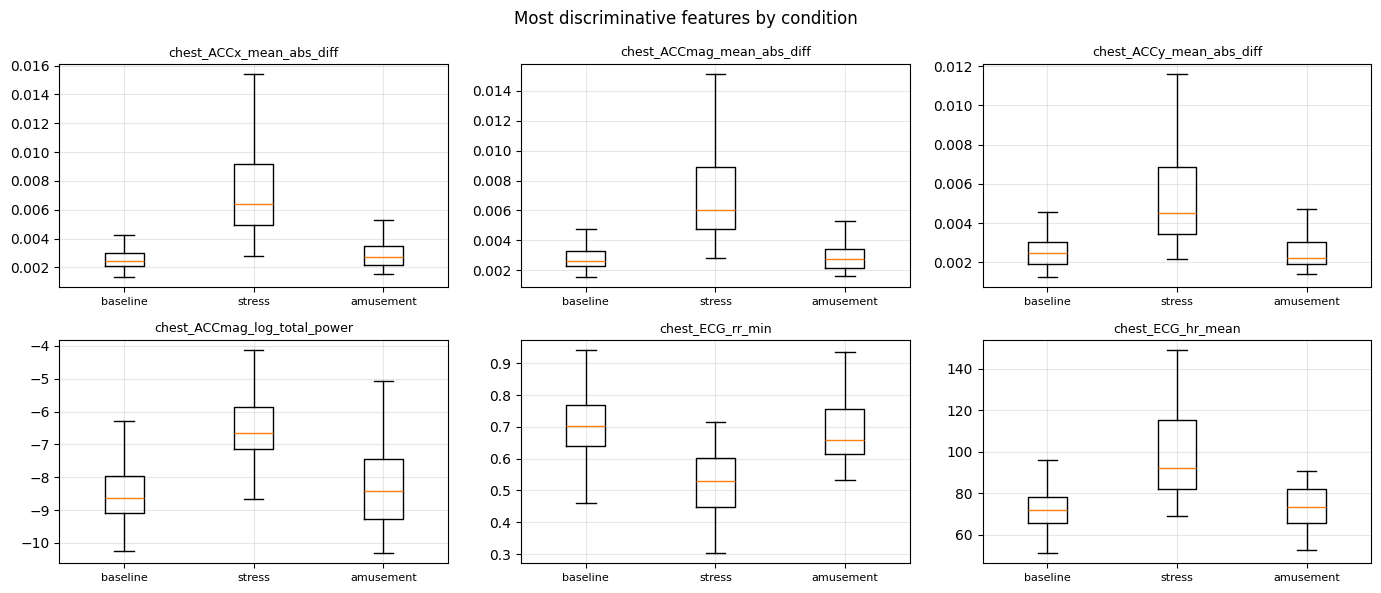

In [57]:
top_feats = anova["feature"].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, feat in zip(axes.ravel(), top_feats):
    data = [df.loc[df["label"] == c, feat].dropna().to_numpy() for c in CLASS_ORDER]
    ax.boxplot(data, showfliers=False)
    # set_xticks instead of boxplot(labels=...): the latter is deprecated in
    # recent matplotlib versions.
    ax.set_xticks(range(1, len(CLASS_ORDER) + 1), CLASS_ORDER)
    ax.set_title(feat, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
plt.suptitle("Most discriminative features by condition")
plt.tight_layout()
plt.show()

## 9d. PCA scatter: is the data separable at all, and does subject identity  dominate the variance?

If the clusters are per-subject rather than per-class, subject-independent generalisation will be hard, which is exactly what the LOSO protocol will measure.

In [58]:
X_all = df[FEATURE_COLS].to_numpy(dtype=np.float64)
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
X_std = StandardScaler().fit_transform(X_all)
pcs = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_std)

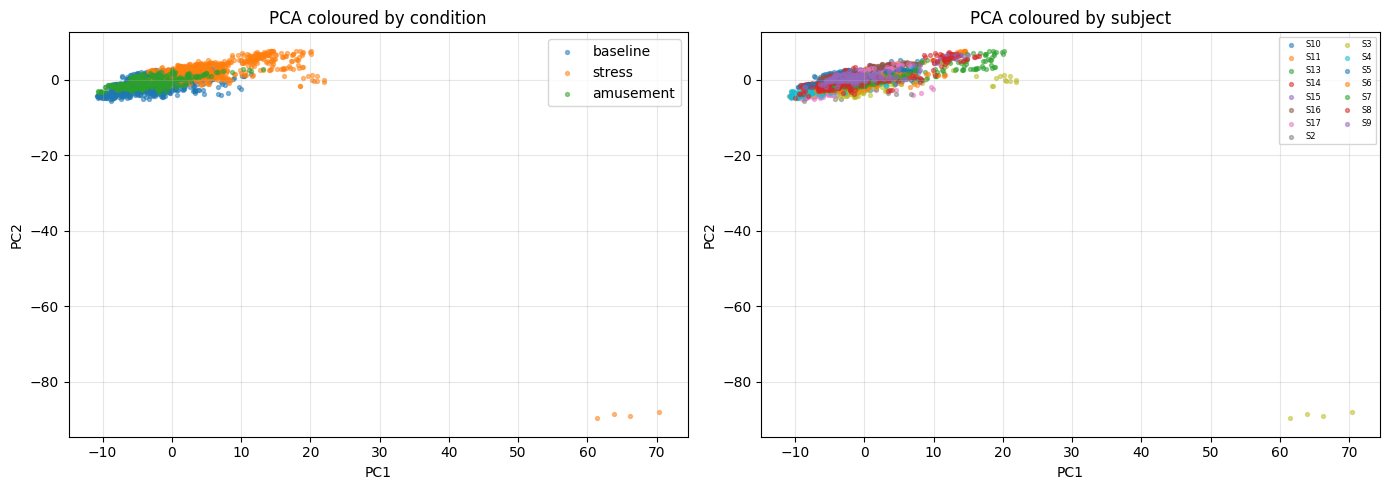

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for c in CLASS_ORDER:
    m = (df["label"] == c).to_numpy()
    axes[0].scatter(pcs[m, 0], pcs[m, 1], s=8, alpha=0.5, label=c)
axes[0].legend()
axes[0].set_title("PCA coloured by condition")
for s in sorted(df["subject"].unique()):
    m = (df["subject"] == s).to_numpy()
    axes[1].scatter(pcs[m, 0], pcs[m, 1], s=8, alpha=0.5, label=s)
axes[1].legend(fontsize=6, ncol=2)
axes[1].set_title("PCA coloured by subject")
for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

# 10. Train/Validation Protocol and Model Definitions

**Protocol**: Leave-One-Subject-Out (LOSO). Physiological baselines differ enormously between people, so a random train/test split would let the model recognise the subject instead of the state, and would additionally leak through the 75 % window overlap. LOSO answers the question that matters: "does this work on a person the model has never seen?"

In [60]:
X = df[FEATURE_COLS].to_numpy(dtype=np.float64)
y_names = df["label"].to_numpy()
groups_subj = df["subject"].to_numpy()

In [61]:
# XGBoost needs integer targets; the encoder also fixes a stable class order.
le = LabelEncoder().fit(CLASS_ORDER)
y = le.transform(y_names)
CLASSES = list(le.classes_)
print("Design matrix:", X.shape, "| classes:", CLASSES)

Design matrix: (2038, 242) | classes: [np.str_('amusement'), np.str_('baseline'), np.str_('stress')]


In [62]:
def make_pipeline(model):
    """Impute -> scale -> model.

    The imputer is a safety net for features that are NaN on degenerate windows.
    Scaling is required by logistic regression and the MLP and harmless for the
    trees. Both steps live inside the pipeline so they are fitted on the
    training subjects only, never on the held-out subject.
    """
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

In [64]:
# Model zoo. class_weight="balanced" matters because baseline is roughly twice
# as frequent as the other conditions.
MODELS = {
    "LogisticRegression": (
        make_pipeline(LogisticRegression(max_iter=2000, class_weight="balanced",
                                        random_state=RANDOM_STATE)),
        {"model__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "RandomForest": (
        make_pipeline(RandomForestClassifier(n_estimators=300, n_jobs=N_JOBS,
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE)),
        {"model__max_depth": [None, 12],
         "model__min_samples_leaf": [1, 2],
         "model__max_features": ["sqrt", 0.3]},
    ),
    "XGBoost": (
        make_pipeline(XGBClassifier(n_estimators=300, learning_rate=0.07,
                                    objective="multi:softprob",
                                    tree_method="hist", n_jobs=N_JOBS,
                                    eval_metric="mlogloss",
                                    random_state=RANDOM_STATE)),
        {"model__max_depth": [3, 5],
         "model__subsample": [0.8, 1.0],
         "model__colsample_bytree": [0.5, 0.7],
         "model__reg_lambda": [1.0, 3.0]},
    ),
    "MLP": (
        make_pipeline(MLPClassifier(max_iter=400, early_stopping=True,
                                    n_iter_no_change=15,
                                    random_state=RANDOM_STATE)),
        {"model__hidden_layer_sizes": [(64,)],
         "model__alpha": [1e-4, 1e-2],}
    ),
}

In [65]:
def tune(name, estimator, grid, X, y, groups, folds=TUNING_FOLDS, scoring="f1_macro"):
    """Grid search with GroupKFold so that no subject is split across folds.

    Scored with macro F1 rather than accuracy: with an imbalanced 3-class
    problem, accuracy rewards a model that simply predicts "baseline".
    """
    cv = GroupKFold(n_splits=folds)
    gs = GridSearchCV(estimator, grid, cv=cv, scoring=scoring,
                      n_jobs=1 if name in ("RandomForest", "XGBoost") else N_JOBS,
                      refit=True, verbose=0)
    t0 = time.time()
    gs.fit(X, y, groups=groups)
    print(f"{name:<20} best {scoring}={gs.best_score_:.4f}  "
          f"({time.time() - t0:.0f} s)  params={gs.best_params_}")
    return gs.best_estimator_, gs.best_params_, gs.best_score_

In [66]:
def run_loso(estimator, X, y, groups, n_classes=None):
    """Leave-One-Subject-Out evaluation.

    Returns out-of-fold predictions/probabilities for every window plus a
    per-subject accuracy table. A fresh clone of the estimator is fitted on each
    fold, so all preprocessing is refitted per fold.
    """
    from sklearn.base import clone

    n_classes = n_classes or len(np.unique(y))
    logo = LeaveOneGroupOut()
    y_pred = np.zeros_like(y)
    y_proba = np.zeros((len(y), n_classes), dtype=float)
    per_subject = []

    for train_idx, test_idx in logo.split(X, y, groups):
        subj = groups[test_idx][0]
        est = clone(estimator)
        est.fit(X[train_idx], y[train_idx])
        pred = est.predict(X[test_idx])
        proba = est.predict_proba(X[test_idx])
        y_pred[test_idx] = pred
        # Map the fold's class columns onto the global class order: a fold can
        # in principle miss a class.
        for j, cls in enumerate(est.classes_):
            y_proba[test_idx, int(cls)] = proba[:, j]
        per_subject.append({
            "subject": subj,
            "n_windows": len(test_idx),
            "accuracy": accuracy_score(y[test_idx], pred),
            "f1_macro": precision_recall_fscore_support(
                y[test_idx], pred, average="macro", zero_division=0)[2],
        })
    return y_pred, y_proba, pd.DataFrame(per_subject)

In [67]:
def score_predictions(y_true, y_pred, y_proba, classes):
    """Aggregate metrics from out-of-fold predictions."""
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    try:
        if len(classes) == 2:
            auc = roc_auc_score(y_true, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    except ValueError:
        auc = np.nan
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
        "roc_auc_ovr": auc,
    }

# 11. Hyperparameter Tuning with Grouped Cross-Validation

**Note on rigour**: tuning here uses all subjects, and section 12 then evaluates with LOSO on the same subjects, so the reported scores are mildly optimistic Section 17 runs a fully nested CV that removes this bias; in practice the gap on WESAD is around 1-2 points.

In [68]:
tuned = {}
for name, (estimator, grid) in MODELS.items():
    best_est, best_params, best_score = tune(name, estimator, grid, X, y, groups_subj)
    tuned[name] = {"estimator": best_est, "params": best_params, "cv_f1": best_score}

LogisticRegression   best f1_macro=0.7334  (11 s)  params={'model__C': 0.01}
RandomForest         best f1_macro=0.7091  (445 s)  params={'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2}
XGBoost              best f1_macro=0.7722  (490 s)  params={'model__colsample_bytree': 0.5, 'model__max_depth': 3, 'model__reg_lambda': 3.0, 'model__subsample': 0.8}
MLP                  best f1_macro=0.7119  (5 s)  params={'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64,)}


# 12. LOSO Evaluation of Tuned Models

In [69]:
results = {}
for name, info in tuned.items():
    t0 = time.time()
    y_pred, y_proba, per_subj = run_loso(info["estimator"], X, y, groups_subj,
                                         n_classes=len(CLASSES))
    metrics = score_predictions(y, y_pred, y_proba, CLASSES)
    results[name] = {"y_pred": y_pred, "y_proba": y_proba,
                     "per_subject": per_subj, "metrics": metrics}
    print(f"{name:<20} acc={metrics['accuracy']:.4f}  "
          f"f1_macro={metrics['f1_macro']:.4f}  "
          f"auc={metrics['roc_auc_ovr']:.4f}  ({time.time() - t0:.0f} s)")

LogisticRegression   acc=0.8670  f1_macro=0.8309  auc=0.9542  (7 s)
RandomForest         acc=0.8145  f1_macro=0.7018  auc=0.9225  (77 s)
XGBoost              acc=0.8548  f1_macro=0.7778  auc=0.9328  (80 s)
MLP                  acc=0.8523  f1_macro=0.8066  auc=0.9545  (6 s)


In [70]:
# Per-class detail for every model.
for name, res in results.items():
    print(f"\n===== {name} (LOSO, out-of-fold) =====")
    print(classification_report(y, res["y_pred"], target_names=CLASSES,
                                digits=3, zero_division=0))


===== LogisticRegression (LOSO, out-of-fold) =====
              precision    recall  f1-score   support

   amusement      0.601     0.759     0.670       315
    baseline      0.941     0.867     0.902      1115
      stress      0.917     0.923     0.920       608

    accuracy                          0.867      2038
   macro avg      0.819     0.850     0.831      2038
weighted avg      0.881     0.867     0.872      2038


===== RandomForest (LOSO, out-of-fold) =====
              precision    recall  f1-score   support

   amusement      0.580     0.254     0.353       315
    baseline      0.808     0.928     0.864      1115
      stress      0.880     0.896     0.888       608

    accuracy                          0.815      2038
   macro avg      0.756     0.693     0.702      2038
weighted avg      0.794     0.815     0.792      2038


===== XGBoost (LOSO, out-of-fold) =====
              precision    recall  f1-score   support

   amusement      0.649     0.435     0.521 

# 13. Model Comparison Tables and Plots

In [71]:
comparison = pd.DataFrame(
    {name: res["metrics"] for name, res in results.items()}
).T.sort_values("f1_macro", ascending=False).round(4)
comparison.insert(0, "cv_f1_tuning", [tuned[n]["cv_f1"] for n in comparison.index])
print("LOSO model comparison (3-class task):")
print(comparison.round(4))

BEST_MODEL = comparison.index[0]
print(f"\nBest model by macro F1: {BEST_MODEL}")

LOSO model comparison (3-class task):
                    cv_f1_tuning  accuracy  balanced_accuracy  precision_macro  recall_macro  f1_macro  roc_auc_ovr
LogisticRegression        0.7334    0.8670             0.8496           0.8193        0.8496    0.8309       0.9542
MLP                       0.7119    0.8523             0.8158           0.7990        0.8158    0.8066       0.9545
XGBoost                   0.7722    0.8548             0.7691           0.8019        0.7691    0.7778       0.9328
RandomForest              0.7091    0.8145             0.6929           0.7560        0.6929    0.7018       0.9225

Best model by macro F1: LogisticRegression


## 13a. Grouped bar chart of the headline metrics.

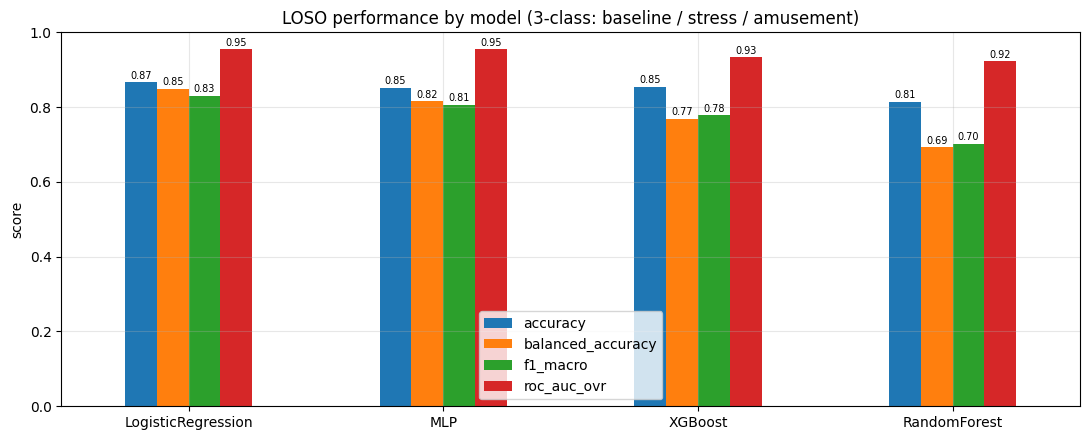

In [72]:
metric_cols = ["accuracy", "balanced_accuracy", "f1_macro", "roc_auc_ovr"]
ax = comparison[metric_cols].plot(kind="bar", figsize=(11, 4.5))
ax.set_ylim(0, 1.0)
ax.set_ylabel("score")
ax.set_title("LOSO performance by model (3-class: baseline / stress / amusement)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=7, padding=1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13b. Per-subject accuracy.

The spread across subjects is the honest measure of how deployable the model is: a high mean with a few very poor subjects means the model fails on some physiologies.

In [73]:
subj_acc = pd.DataFrame({
    name: res["per_subject"].set_index("subject")["accuracy"]
    for name, res in results.items()
})
print("\nPer-subject LOSO accuracy:")
print(subj_acc.round(3))
print("\nMean +/- std across subjects:")
print(pd.DataFrame({"mean": subj_acc.mean(), "std": subj_acc.std()}).round(3))


Per-subject LOSO accuracy:
         LogisticRegression  RandomForest  XGBoost    MLP
subject                                                  
S10                   0.893         0.786    0.850  0.836
S11                   0.912         0.927    1.000  0.956
S13                   0.766         0.730    0.730  0.766
S14                   0.935         0.471    0.674  0.928
S15                   0.796         0.912    0.927  0.832
S16                   0.599         0.905    0.898  0.555
S17                   0.957         0.835    0.842  0.957
S2                    0.837         0.806    0.798  0.798
S3                    0.902         0.780    0.902  0.932
S4                    0.873         0.821    0.828  0.858
S5                    0.956         0.956    0.875  0.926
S6                    0.941         0.846    0.919  0.926
S7                    0.852         0.830    0.815  0.726
S8                    0.919         0.846    0.838  0.897
S9                    0.867         0.770   

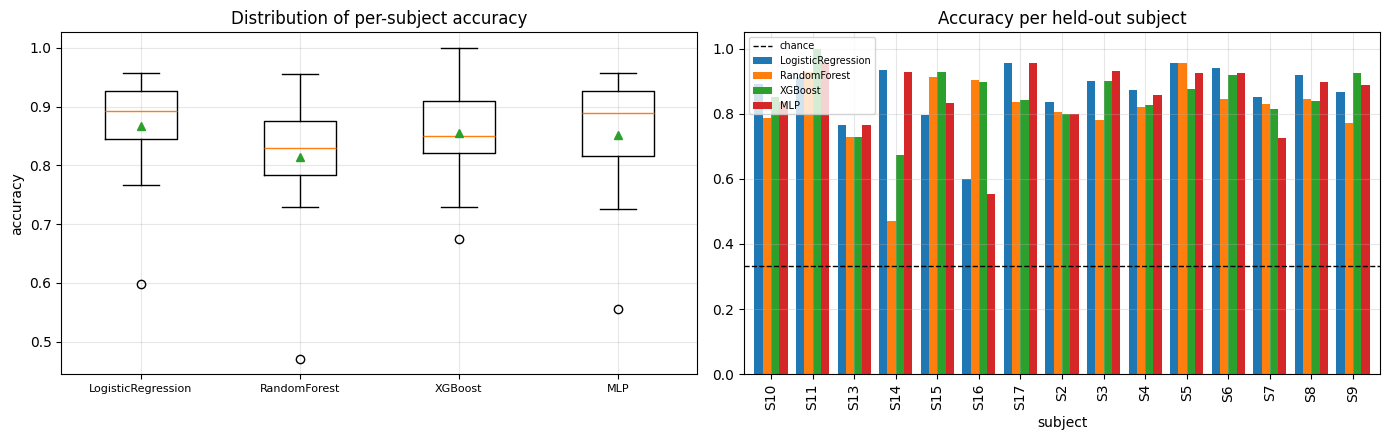

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].boxplot([subj_acc[c].to_numpy() for c in subj_acc.columns], showmeans=True)
axes[0].set_xticks(range(1, len(subj_acc.columns) + 1), list(subj_acc.columns))
axes[0].set_ylabel("accuracy")
axes[0].set_title("Distribution of per-subject accuracy")
axes[0].tick_params(axis="x", labelsize=8)
subj_acc.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].axhline(1.0 / len(CLASSES), ls="--", c="k", lw=1, label="chance")
axes[1].set_title("Accuracy per held-out subject")
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# 14. Confusion Matrices and ROC Curves

In [75]:
def plot_confusion(ax, y_true, y_pred, classes, title, normalize=True):
    """Row-normalised confusion matrix: each row shows how a true class was
    distributed over the predictions (i.e. per-class recall on the diagonal)."""
    cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))
    shown = cm.astype(float) / cm.sum(axis=1, keepdims=True) if normalize else cm
    im = ax.imshow(shown, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    ax.set_xticks(range(len(classes)), classes, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(classes)), classes, fontsize=8)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title, fontsize=10)
    ax.grid(False)
    for i in range(len(classes)):
        for j in range(len(classes)):
            txt = f"{shown[i, j]:.2f}\n({cm[i, j]})" if normalize else f"{cm[i, j]}"
            ax.text(j, i, txt, ha="center", va="center", fontsize=7,
                    color="white" if shown[i, j] > 0.5 * np.nanmax(shown) else "black")
    return im

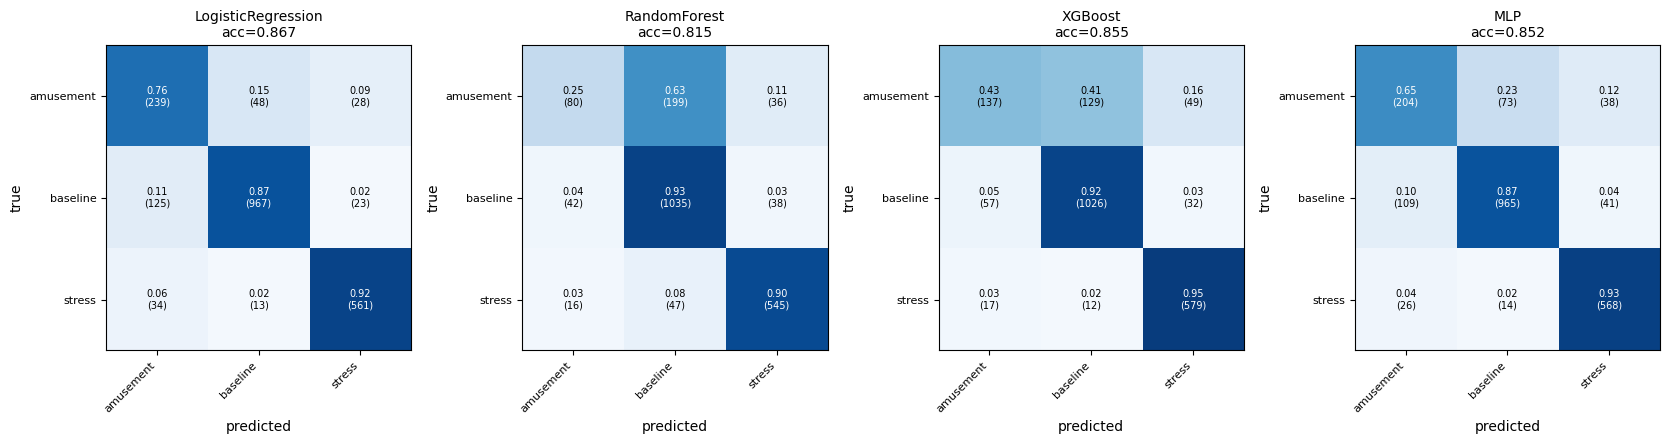

In [76]:
fig, axes = plt.subplots(1, len(results), figsize=(4.2 * len(results), 4.2))
for ax, (name, res) in zip(np.atleast_1d(axes), results.items()):
    plot_confusion(ax, y, res["y_pred"], CLASSES,
                   f"{name}\nacc={res['metrics']['accuracy']:.3f}")
plt.tight_layout()
plt.show()

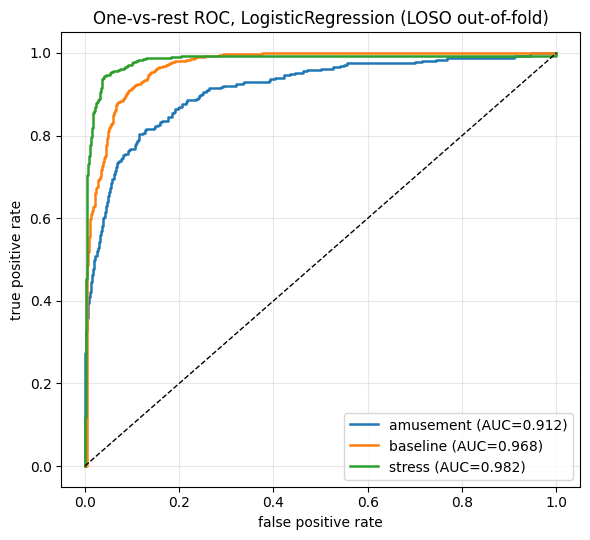

In [77]:
# One-vs-rest ROC curves for the best model.
fig, ax = plt.subplots(figsize=(6, 5.5))
proba = results[BEST_MODEL]["y_proba"]
for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve((y == i).astype(int), proba[:, i])
    auc_i = roc_auc_score((y == i).astype(int), proba[:, i])
    ax.plot(fpr, tpr, lw=1.8, label=f"{cls} (AUC={auc_i:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title(f"One-vs-rest ROC, {BEST_MODEL} (LOSO out-of-fold)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 15. Feature Importance

Importances come from a model refitted on all subjects. They are a description of what the model uses, not a causal claim: correlated features (many of them here) share and dilute each other's importance.

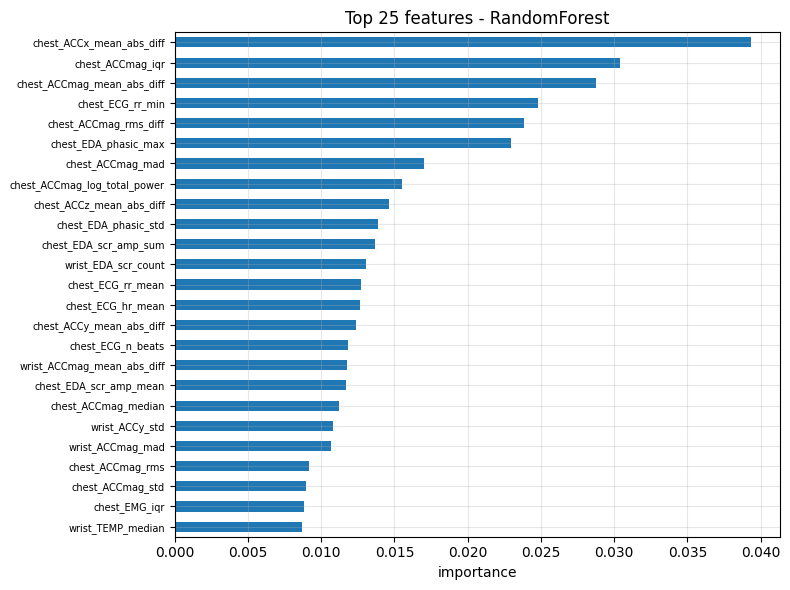


RandomForest: importance aggregated per sensor
chest_ACCmag    18.2
chest_EDA       11.3
chest_ECG        9.8
chest_EMG        8.5
chest_Resp       7.4
wrist_EDA        7.3
wrist_ACCmag     6.2
chest_ACCx       5.9
wrist_TEMP       5.2
wrist_ACCz       3.7
chest_Temp       3.6
chest_ACCz       2.8
wrist_BVP        2.7
wrist_ACCx       2.6
wrist_ACCy       2.5


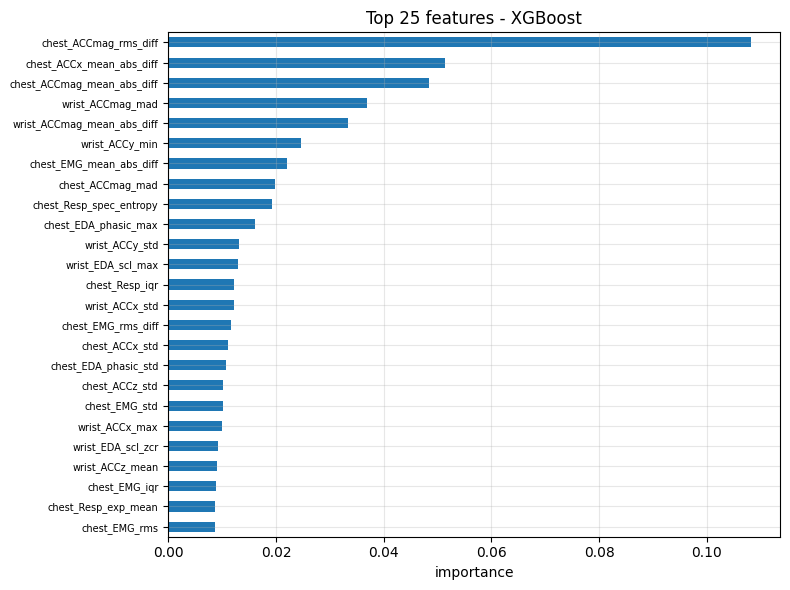


XGBoost: importance aggregated per sensor
chest_ACCmag    23.5
chest_EMG       10.2
wrist_ACCmag     9.6
chest_Resp       8.5
chest_EDA        8.0
wrist_EDA        7.2
chest_ACCx       6.8
chest_ECG        5.8
wrist_ACCy       4.2
wrist_ACCx       3.5
wrist_TEMP       3.4
chest_Temp       3.0
wrist_ACCz       2.7
chest_ACCz       1.5
wrist_BVP        1.3


In [78]:
for name in ["RandomForest", "XGBoost"]:
    if name not in tuned:
        continue
    est = tuned[name]["estimator"]
    est.fit(X, y)
    imp = est.named_steps["model"].feature_importances_
    imp_s = pd.Series(imp, index=FEATURE_COLS).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    imp_s.head(25)[::-1].plot(kind="barh", ax=ax)
    ax.set_title(f"Top 25 features - {name}")
    ax.set_xlabel("importance")
    ax.tick_params(axis="y", labelsize=7)
    plt.tight_layout()
    plt.show()

    # Aggregate importance by sensor to see which device carries the signal.
    def sensor_of(col):
        parts = col.split("_")
        return "_".join(parts[:2]) if len(parts) > 1 else col

    by_sensor = imp_s.groupby(sensor_of).sum().sort_values(ascending=False)
    print(f"\n{name}: importance aggregated per sensor")
    print((by_sensor * 100).round(1).head(15).to_string())

# 16. Binary Task: Stress vs Non-Stress

The application-relevant task: detect stress against everything else. It is easier than the 3-class problem and gives a single clean ROC-AUC.

In [79]:
y_bin = (y_names == "stress").astype(int)
BIN_CLASSES = ["non_stress", "stress"]
print("Binary class balance:", dict(zip(*np.unique(y_bin, return_counts=True))))

bin_models = {
    "RandomForest": (
        make_pipeline(RandomForestClassifier(n_estimators=400, n_jobs=N_JOBS,
                                             class_weight="balanced",
                                             random_state=RANDOM_STATE)),
        {"model__max_depth": [None, 12], "model__min_samples_leaf": [1, 3]},
    ),
    "XGBoost": (
        make_pipeline(XGBClassifier(n_estimators=400, learning_rate=0.05,
                                    objective="binary:logistic",
                                    tree_method="hist", n_jobs=N_JOBS,
                                    eval_metric="logloss",
                                    # Counteract the ~2:1 imbalance.
                                    scale_pos_weight=float((y_bin == 0).sum() / max(1, (y_bin == 1).sum())),
                                    random_state=RANDOM_STATE)),
        {"model__max_depth": [3, 5], "model__subsample": [0.8, 1.0],
         "model__colsample_bytree": [0.5, 0.8]},
    ),
}

Binary class balance: {np.int64(0): np.int64(1430), np.int64(1): np.int64(608)}


In [80]:
bin_results = {}
for name, (estimator, grid) in bin_models.items():
    best_est, _, _ = tune(f"[bin] {name}", estimator, grid, X, y_bin, groups_subj,
                          scoring="f1")
    y_pred_b, y_proba_b, per_subj_b = run_loso(best_est, X, y_bin, groups_subj,
                                               n_classes=2)
    m = score_predictions(y_bin, y_pred_b, y_proba_b, BIN_CLASSES)
    bin_results[name] = {"metrics": m, "y_pred": y_pred_b, "y_proba": y_proba_b,
                         "per_subject": per_subj_b}
    print(f"[bin] {name:<15} acc={m['accuracy']:.4f}  f1={m['f1_macro']:.4f}  "
          f"auc={m['roc_auc_ovr']:.4f}")

bin_comparison = pd.DataFrame(
    {n: r["metrics"] for n, r in bin_results.items()}).T.round(4)
print("\nBinary stress detection (LOSO):")
print(bin_comparison)

[bin] RandomForest   best f1=0.8171  (113 s)  params={'model__max_depth': None, 'model__min_samples_leaf': 3}
[bin] RandomForest    acc=0.9338  f1=0.9203  auc=0.9840
[bin] XGBoost        best f1=0.8683  (69 s)  params={'model__colsample_bytree': 0.5, 'model__max_depth': 3, 'model__subsample': 1.0}
[bin] XGBoost         acc=0.9396  f1=0.9294  auc=0.9853

Binary stress detection (LOSO):
              accuracy  balanced_accuracy  precision_macro  recall_macro  f1_macro  roc_auc_ovr
RandomForest    0.9338             0.9173           0.9235        0.9173    0.9203       0.9840
XGBoost         0.9396             0.9390           0.9214        0.9390    0.9294       0.9853


In [81]:
best_bin = bin_comparison["f1_macro"].idxmax()
print(f"\nDetailed report for {best_bin}:")
print(classification_report(y_bin, bin_results[best_bin]["y_pred"],
                            target_names=BIN_CLASSES, digits=3, zero_division=0))


Detailed report for XGBoost:
              precision    recall  f1-score   support

  non_stress      0.973     0.941     0.956      1430
      stress      0.870     0.938     0.903       608

    accuracy                          0.940      2038
   macro avg      0.921     0.939     0.929      2038
weighted avg      0.942     0.940     0.940      2038



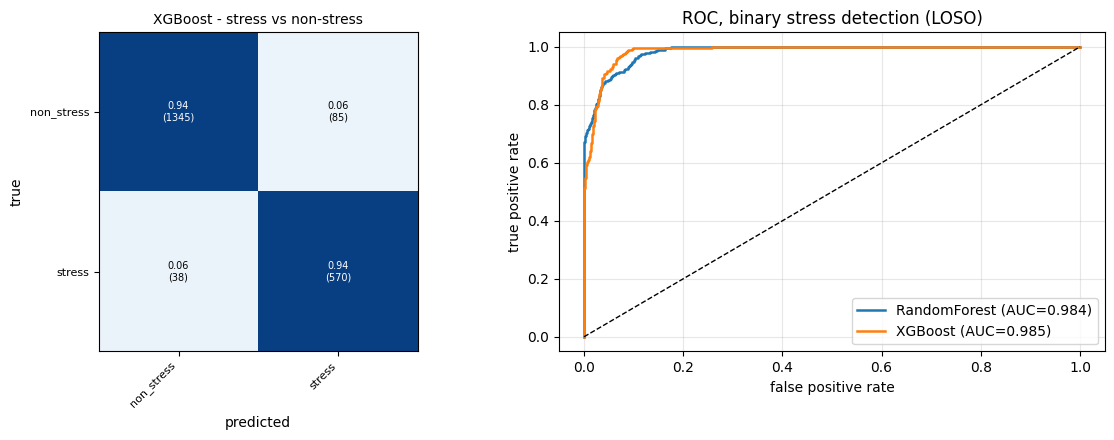

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(axes[0], y_bin, bin_results[best_bin]["y_pred"], BIN_CLASSES,
               f"{best_bin} - stress vs non-stress")
for name, r in bin_results.items():
    fpr, tpr, _ = roc_curve(y_bin, r["y_proba"][:, 1])
    axes[1].plot(fpr, tpr, lw=1.8,
                 label=f"{name} (AUC={r['metrics']['roc_auc_ovr']:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC, binary stress detection (LOSO)")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

# 17. Optional: Nested Cross-Validation (unbiased estimate)

Outer loop = LOSO, inner loop = GroupKFold grid search on the training subjects only. This removes the optimism of tuning on all subjects, at ~15x the cost. Set RUN_NESTED_CV = True in section 2 to run it.

In [83]:
def nested_loso(estimator, grid, X, y, groups, inner_folds=4, scoring="f1_macro"):
    from sklearn.base import clone
    logo = LeaveOneGroupOut()
    y_pred = np.zeros_like(y)
    y_proba = np.zeros((len(y), len(np.unique(y))))
    for train_idx, test_idx in logo.split(X, y, groups):
        gtr = groups[train_idx]
        inner = GroupKFold(n_splits=min(inner_folds, len(np.unique(gtr))))
        gs = GridSearchCV(clone(estimator), grid, cv=inner, scoring=scoring, n_jobs=1)
        gs.fit(X[train_idx], y[train_idx], groups=gtr)
        y_pred[test_idx] = gs.predict(X[test_idx])
        proba = gs.predict_proba(X[test_idx])
        for j, cls in enumerate(gs.best_estimator_.classes_):
            y_proba[test_idx, int(cls)] = proba[:, j]
        print(f"  fold {groups[test_idx][0]}: best={gs.best_params_}")
    return y_pred, y_proba


if RUN_NESTED_CV:
    est, grid = MODELS[BEST_MODEL]
    print(f"Nested LOSO for {BEST_MODEL} (this takes a while)...")
    yp, ypr = nested_loso(est, grid, X, y, groups_subj)
    nested_metrics = score_predictions(y, yp, ypr, CLASSES)
    print("\nNested (unbiased) LOSO metrics:")
    print(pd.Series(nested_metrics).round(4))
    print("\nCompared to the non-nested estimate:")
    print(pd.Series(results[BEST_MODEL]["metrics"]).round(4))
else:
    print("Nested CV skipped (set RUN_NESTED_CV = True in section 2 to enable).")

Nested CV skipped (set RUN_NESTED_CV = True in section 2 to enable).


# 18. Conclusions and Suggestions for Improvement

In [84]:
print("=" * 78)
print("SUMMARY")
print("=" * 78)
print(f"Subjects: {df['subject'].nunique()} | windows: {len(df)} | "
      f"features: {len(FEATURE_COLS)}")
print(f"Window: {WINDOW_SEC:.0f} s with {STEP_SEC:.0f} s step "
      f"({100 * (1 - STEP_SEC / WINDOW_SEC):.0f}% overlap)")
print("\n3-class task (baseline / stress / amusement), LOSO:")
print(comparison[metric_cols].round(4).to_string())
print("\nBinary task (stress vs non-stress), LOSO:")
print(bin_comparison[metric_cols].round(4).to_string())
print("\nPer-subject accuracy of the best 3-class model "
      f"({BEST_MODEL}): mean={subj_acc[BEST_MODEL].mean():.3f}, "
      f"std={subj_acc[BEST_MODEL].std():.3f}, "
      f"worst={subj_acc[BEST_MODEL].min():.3f} "
      f"({subj_acc[BEST_MODEL].idxmin()})")
print("=" * 78)

SUMMARY
Subjects: 15 | windows: 2038 | features: 242
Window: 60 s with 15 s step (75% overlap)

3-class task (baseline / stress / amusement), LOSO:
                    accuracy  balanced_accuracy  f1_macro  roc_auc_ovr
LogisticRegression    0.8670             0.8496    0.8309       0.9542
MLP                   0.8523             0.8158    0.8066       0.9545
XGBoost               0.8548             0.7691    0.7778       0.9328
RandomForest          0.8145             0.6929    0.7018       0.9225

Binary task (stress vs non-stress), LOSO:
              accuracy  balanced_accuracy  f1_macro  roc_auc_ovr
RandomForest    0.9338             0.9173    0.9203       0.9840
XGBoost         0.9396             0.9390    0.9294       0.9853

Per-subject accuracy of the best 3-class model (LogisticRegression): mean=0.867, std=0.093, worst=0.599 (S16)


Under a strict Leave-One-Subject-Out protocol on all 15 subjects (2038 windows of 60 s with 75 % overlap, 242 hand-crafted features), the pipeline reaches 86.7 % accuracy and 0.831 macro F1 on the three-class problem (baseline / stress / amusement) and 94.0 % accuracy with 0.985 ROC-AUC on the binary stress-detection task, which is in line with the results reported in the original WESAD study and confirms that the extracted physiological features generalise to unseen people. The most informative result is the model ranking: regularised logistic regression (acc = 0.867, balanced acc = 0.850) outperforms both gradient boosting and the random forest, whose accuracy looks acceptable (0.855 and 0.815) but whose balanced accuracy collapses to 0.769 and 0.693 because they largely fail on the minority amusement class and drift towards predicting baseline; with only 15 subjects and a few hundred correlated features, the high-bias linear model is simply the better inductive bias, while the tree ensembles fit subject-specific patterns that do not transfer. The trees remain competitive once the task is reduced to stress vs non-stress (XGBoost: balanced acc = 0.939), which shows that the difficulty of the three-class task lies in separating mild positive arousal from rest rather than in detecting stress itself. Finally, the between-subject spread is the main obstacle to deployment: per-subject accuracy of the best model is 0.867 ± 0.093 with a worst case of 0.599 (S16), so a population-level model alone is not sufficient and subject-wise baseline normalisation or light personalisation should be the next step.